# Матрица диаграмм рассеяния

In [114]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [115]:
conn = sqlite3.connect('../data/checking-logs.sqlite')
ab_df = pd.read_csv('../data/ab-test.csv')

query = """
select uid, count(*) as commit_count from checker where labname <> 'project1' and uid LIKE 'user_%' group by uid
"""

df = pd.read_sql(query, conn)
df

,uid,commit_count
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86
5,user_13,52
6,user_14,61
7,user_15,23
8,user_16,41
9,user_17,51


In [116]:
ab_df_test = ab_df.loc[ab_df['group'] == 'test']
ab_df_test_uid = ab_df_test['uid'].unique()
ab_df_test_uid

<StringArray>
['user_1', 'user_18', 'user_19', 'user_21', 'user_25', 'user_28', 'user_3']
Length: 7, dtype: str

In [117]:
commits_df = df.loc[df['uid'].isin(ab_df_test_uid)] ## Таблица количества коммитов для пользователей из группы tests
commits_df

,uid,commit_count
1,user_1,62
10,user_18,5
11,user_19,118
14,user_21,65
18,user_25,79
21,user_28,60
23,user_3,18


In [118]:
query = """
select uid, count(*) as views_count from pageviews where uid LIKE 'user_%' group by uid
"""

views_df = pd.read_sql(query, conn)
views_test_df = views_df.loc[views_df['uid'].isin(ab_df_test_uid)]
views_test_df # Таблица количества просмотров страницы для пользователей из группы tests

,uid,views_count
0,user_1,28
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


In [119]:
query = """
with first_commit as (select uid, labname, MIN(timestamp) as timestamp from checker where checker.uid like 'user_%' and checker.labname <> 'project1' group by uid, labname),
a as (select first_commit.uid, (strftime('%s', first_commit.timestamp) - deadlines.deadlines) / 3600 as diff from first_commit
join deadlines 
on deadlines.labs = first_commit.labname)
select uid, AVG(diff) as avg_diff from a group by uid
"""

diff_df = pd.read_sql(query, conn)
diff_df = diff_df.loc[diff_df['uid'].isin(ab_df_test_uid)]
diff_df

,uid,avg_diff
0,user_1,-64.400000
9,user_18,-5.666667
10,user_19,-98.750000
13,user_21,-95.500000
17,user_25,-92.600000
20,user_28,-86.400000
22,user_3,-105.400000


In [120]:
result_df = commits_df.merge(diff_df, how='inner', on='uid')
result_df = result_df.merge(views_test_df, how='inner', on='uid')
result_df


,uid,commit_count,avg_diff,views_count
0,user_1,62,-64.400000,28
1,user_18,5,-5.666667,3
2,user_19,118,-98.750000,16
3,user_21,65,-95.500000,10
4,user_25,79,-92.600000,179
5,user_28,60,-86.400000,149
6,user_3,18,-105.400000,317


array([[<Axes: xlabel='avg_diff', ylabel='avg_diff'>,
        <Axes: xlabel='views_count', ylabel='avg_diff'>,
        <Axes: xlabel='commit_count', ylabel='avg_diff'>],
       [<Axes: xlabel='avg_diff', ylabel='views_count'>,
        <Axes: xlabel='views_count', ylabel='views_count'>,
        <Axes: xlabel='commit_count', ylabel='views_count'>],
       [<Axes: xlabel='avg_diff', ylabel='commit_count'>,
        <Axes: xlabel='views_count', ylabel='commit_count'>,
        <Axes: xlabel='commit_count', ylabel='commit_count'>]],
      dtype=object)

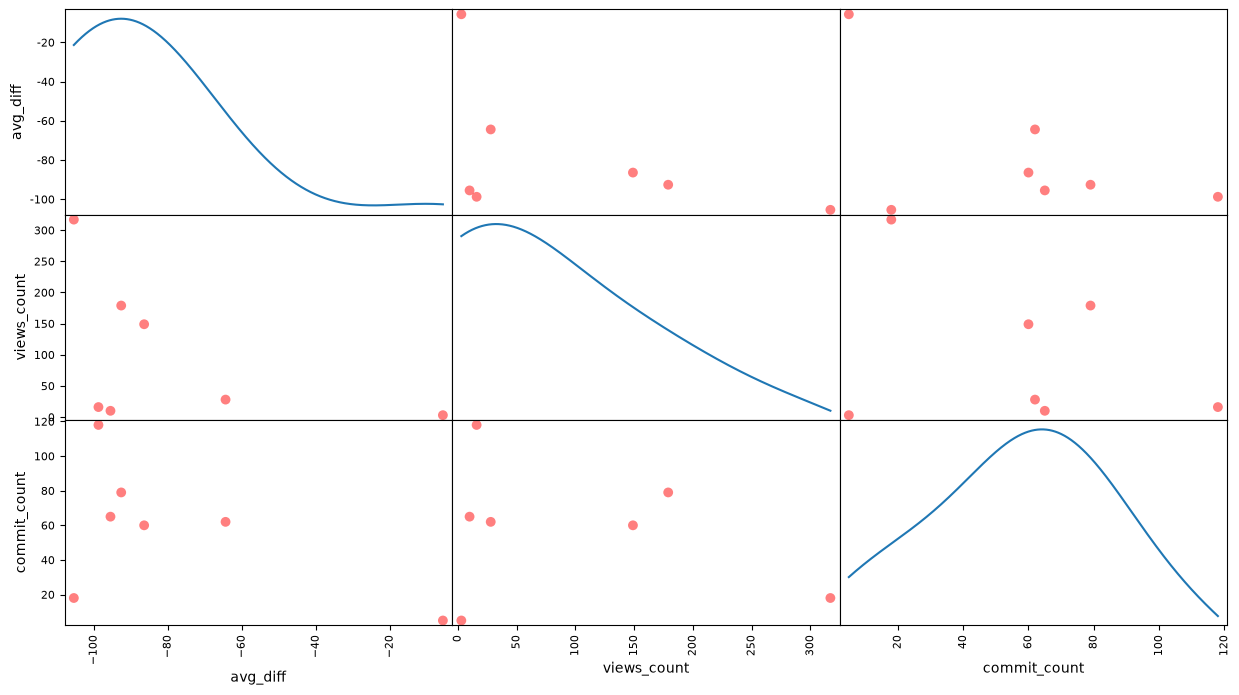

In [121]:
scatter_matrix(
    result_df[['avg_diff', 'views_count', 'commit_count']],
    figsize=(15, 8),
    diagonal='kde',
    s=200,
    color='red'
)

## Вопросы по графику

Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, мало коммитов?

**Нет**

Можно ли сказать, что если у пользователя мало просмотров ленты, то у него, вероятно, малая средняя разница между первым коммитом и дедлайном лабораторной?

**Нет.** 

Можно ли сказать, что много пользователей с малым числом коммитов и немного — с большим числом коммитов?

**Нет.** 

Можно ли сказать, что много пользователей с малой средней разницей и немного — с большой средней разницей?

**Нет.** 